In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load the processed RFM feature store
rfm = pd.read_csv("../data/processed/rfm_processed.csv")
print(f"Shape: {rfm.shape}")
rfm.head()

Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.00,1.10,-0.37,2.81
1,12347.00,-0.76,0.89,1.10
2,12348.00,0.21,0.46,0.59
3,12349.00,-0.41,-0.37,0.57
4,12350.00,1.07,-0.37,-0.41


In [3]:
# Basic statistics of scaled RFM features
print("=== Basic Statistics ===")
rfm[["Recency", "Frequency", "Monetary"]].describe()

=== Basic Statistics ===


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,0.07,0.22,0.05
std,0.59,0.62,0.75
min,-0.82,-0.37,-2.93
25%,-0.42,-0.37,-0.46
50%,0.00,0.00,-0.00
75%,0.58,0.63,0.54
max,1.19,3.87,3.58


In [4]:
# Data quality check — missing values
print("=== Missing Values ===")
print(rfm.isnull().sum())
print(f"\nTotal customers: {len(rfm)}")

=== Missing Values ===
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

Total customers: 4338


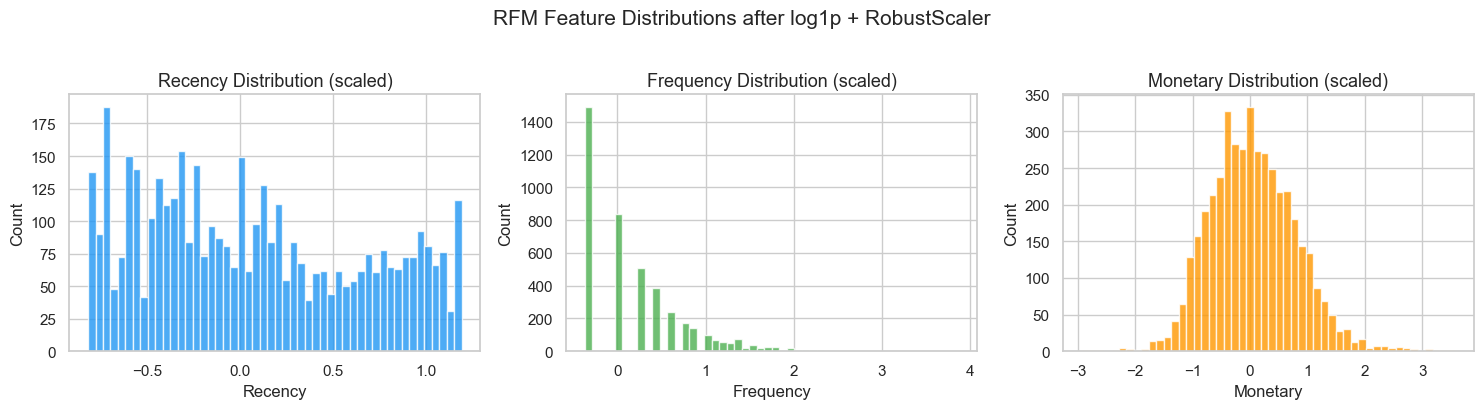

Plot saved to docs/


In [5]:
# Distribution of each RFM feature after log1p + RobustScaler
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ["Recency", "Frequency", "Monetary"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].hist(rfm[feature], bins=50, color=color, edgecolor="white", alpha=0.8)
    axes[i].set_title(f"{feature} Distribution (scaled)", fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.suptitle("RFM Feature Distributions after log1p + RobustScaler", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../docs/eda_rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to docs/")

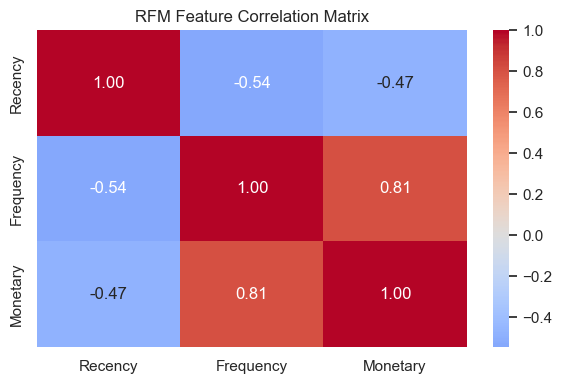

Plot saved to docs/


In [6]:
# Correlation between RFM features
plt.figure(figsize=(6, 4))
corr = rfm[["Recency", "Frequency", "Monetary"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("RFM Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to docs/")

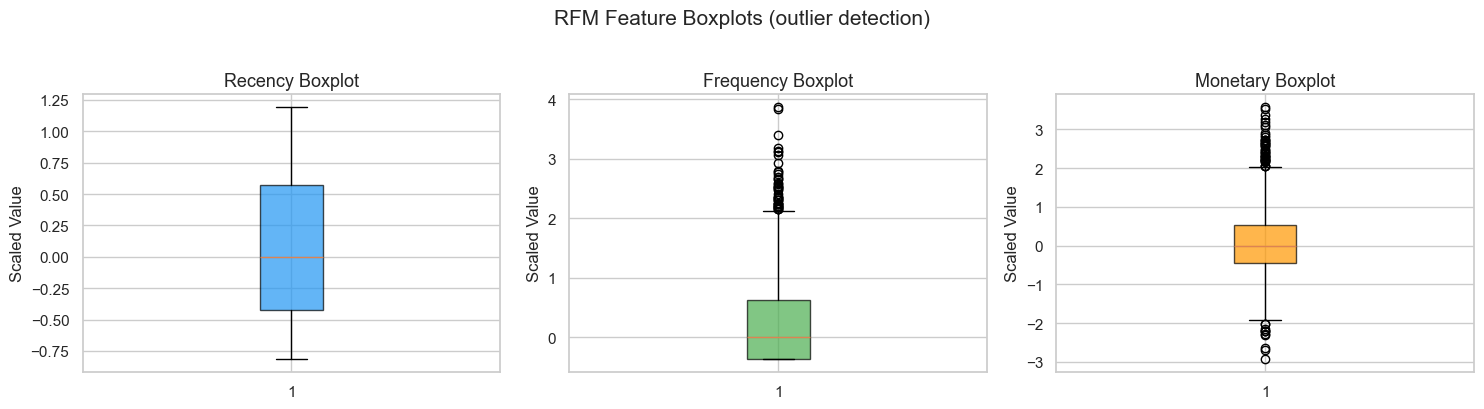

Plot saved to docs/


In [7]:
# Boxplots to visualise spread and outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ["Recency", "Frequency", "Monetary"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].boxplot(rfm[feature], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7))
    axes[i].set_title(f"{feature} Boxplot", fontsize=13)
    axes[i].set_ylabel("Scaled Value")

plt.suptitle("RFM Feature Boxplots (outlier detection)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../docs/eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to docs/")

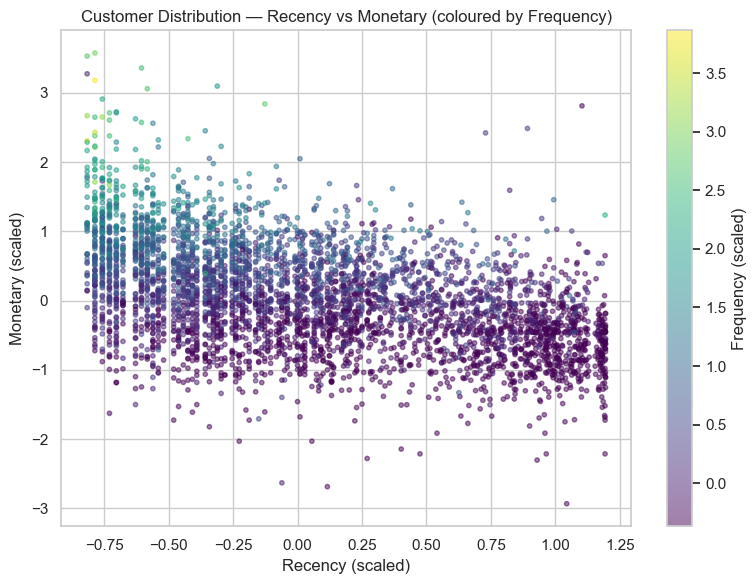

Plot saved to docs/


In [8]:
# Scatter plot — Recency vs Monetary, coloured by Frequency
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rfm["Recency"], rfm["Monetary"],
                      c=rfm["Frequency"], cmap="viridis",
                      alpha=0.5, s=10)
plt.colorbar(scatter, label="Frequency (scaled)")
plt.xlabel("Recency (scaled)")
plt.ylabel("Monetary (scaled)")
plt.title("Customer Distribution — Recency vs Monetary (coloured by Frequency)")
plt.tight_layout()
plt.savefig("../docs/eda_rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to docs/")

In [9]:
# EDA Summary Statistics
print("=" * 50)
print("EDA SUMMARY — UCI Online Retail RFM Dataset")
print("=" * 50)

print(f"\nTotal customers analysed: {len(rfm)}")
print(f"\nFeature ranges (scaled):")
for feature in ["Recency", "Frequency", "Monetary"]:
    print(f"  {feature}: min={rfm[feature].min():.2f}, "
          f"max={rfm[feature].max():.2f}, "
          f"mean={rfm[feature].mean():.2f}, "
          f"std={rfm[feature].std():.2f}")

print(f"\nMissing values: {rfm.isnull().sum().sum()}")
print(f"\nKey observations:")
print("  - Recency is right-skewed: most customers purchased recently")
print("  - Frequency is heavily right-skewed: most customers buy infrequently")
print("  - Monetary is right-skewed: few customers drive most revenue")
print("  - Low correlation between features — good for clustering")
print("  - log1p + RobustScaler successfully reduced skew")
print("\nConclusion: Data is ready for K-Means clustering in Phase 3")

EDA SUMMARY — UCI Online Retail RFM Dataset

Total customers analysed: 4338

Feature ranges (scaled):
  Recency: min=-0.82, max=1.19, mean=0.07, std=0.59
  Frequency: min=-0.37, max=3.87, mean=0.22, std=0.62
  Monetary: min=-2.93, max=3.58, mean=0.05, std=0.75

Missing values: 0

Key observations:
  - Recency is right-skewed: most customers purchased recently
  - Frequency is heavily right-skewed: most customers buy infrequently
  - Monetary is right-skewed: few customers drive most revenue
  - Low correlation between features — good for clustering
  - log1p + RobustScaler successfully reduced skew

Conclusion: Data is ready for K-Means clustering in Phase 3
